In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/phhasian0710/seed-iv/Channel Order.xlsx
/kaggle/input/datasets/phhasian0710/seed-iv/ReadMe.txt
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/4_20151118.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/14_20151208.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/5_20160413.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/3_20151018.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/6_20150511.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/15_20150514.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/10_20151021.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/12_20150804.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/13_20151125.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/11_20150921.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/8_20151110.

In [2]:
# Install required packages
!pip install torch numpy scipy pandas scikit-learn tqdm

In [3]:
import os
import glob
import time
import math
import pickle
import random
from collections import Counter
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

Installation & Dependencies (Run First)


In [4]:
!pip install mne PyWavelets scikit-learn tqdm matplotlib seaborn pandas scipy numpy torch torchvision torchaudio

In [5]:
!pip install mne PyWavelets scikit-learn tqdm matplotlib seaborn pandas scipy numpy torch torchvision torchaudio

##########

In [14]:
# CELL 1: IMPORTS AND CONFIGURATION
# ============================================================================

import os
import glob
import time
import math
import pickle
import random
from collections import Counter
from itertools import permutations

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.stats import entropy, kurtosis, zscore
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

# ===== SET SEED FUNCTION =====
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ Seed set to {seed}")

# ===== CONFIGURATION =====
class Config:
    DATA_PATH = '/kaggle/input/datasets/phhasian0710/seed-iv/eeg_feature_smooth/'
    OUTPUT_PATH = './processed_data/'
    MODEL_PATH = './saved_models/'
    RESULTS_PATH = './results/'
    
    NUM_SUBJECTS = 15
    NUM_CLASSES = 4
    NUM_CHANNELS = 62
    NUM_SESSIONS = 3
    TRIALS_PER_SESSION = 24
    
    TRIAL_EMOTION_MAPPING = [1, 2, 3, 0, 2, 0, 0, 1, 0, 1, 2, 1,
                             1, 1, 2, 3, 2, 2, 3, 3, 0, 3, 0, 3]
    EMOTION_NAMES = {0: 'Neutral', 1: 'Sad', 2: 'Fear', 3: 'Happy'}
    
    USE_MULTI_SCALE = True
    SCALE_KERNELS = [3, 5, 7]
    
    USE_REGION_AWARE = True
    REGION_MAPPING = {
        'frontal': list(range(1, 15)),
        'central': list(range(15, 25)),
        'parietal': list(range(25, 37)),
        'temporal': list(range(37, 49)),
        'occipital': list(range(49, 63))
    }
    
    FEATURE_TYPES = ['DE', 'PSD', 'SE', 'PE']
    NUM_FREQ_BANDS = 5
    TOTAL_FEATURES = len(FEATURE_TYPES) * NUM_FREQ_BANDS
    
    TARGET_TIME_LENGTH = 35
    
    USE_AUGMENTATION = True
    AUGMENTATION_TYPES = ['noise', 'mixup']
    NOISE_STD = 0.05
    MIXUP_ALPHA = 0.4
    
    USE_CONTRASTIVE = True
    CONTRASTIVE_TEMPERATURE = 0.5
    CONTRASTIVE_WEIGHT = 0.15
    
    USE_FOCAL_LOSS = True
    FOCAL_GAMMA = 2.0
    FOCAL_ALPHA = [0.25, 0.25, 0.25, 0.25]
    
    # ── Lightweight settings ──
    USE_ATTENTION = False           # disable → big speed & param saving
    USE_TEMPORAL = True
    DROPOUT = 0.4
    NUM_ATTENTION_HEADS = 2
    HIDDEN_DIM = 64                 # reduced from 128
    BILSTM_LAYERS = 2
    TOPK_GRAPH = 8
    
    BATCH_SIZE = 32                 # increased
    LEARNING_RATE = 0.001           # increased for smaller model
    WEIGHT_DECAY = 0.0001
    EPOCHS = 120
    PATIENCE = 20
    SEED = 42

# Create directories
for path in [Config.OUTPUT_PATH, Config.MODEL_PATH, Config.RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(Config.SEED)

print("="*60)
print("LIGHTWEIGHT ENHANCED CONFIGURATION")
print("="*60)
print(f"Device: {device}")
print(f"Multi-scale: {Config.USE_MULTI_SCALE}")
print(f"Region-aware: {Config.USE_REGION_AWARE}")
print(f"Augmentation: {Config.USE_AUGMENTATION}")
print(f"Contrastive: {Config.USE_CONTRASTIVE}")
print(f"Focal loss: {Config.USE_FOCAL_LOSS}")
print(f"Features: {Config.FEATURE_TYPES} → {Config.TOTAL_FEATURES}")
print("="*60)

✓ Seed set to 42
LIGHTWEIGHT ENHANCED CONFIGURATION
Device: cuda
Multi-scale: True
Region-aware: True
Augmentation: True
Contrastive: True
Focal loss: True
Features: ['DE', 'PSD', 'SE', 'PE'] → 20


In [10]:
# CELL 2: DATA PREPROCESSOR
# ============================================================================

class SEEDIVDataPreprocessor:
    """Load and preprocess SEED-IV dataset"""
    
    def __init__(self, config):
        self.config = config
        self.trial_order = config.TRIAL_EMOTION_MAPPING
        self.emotion_names = config.EMOTION_NAMES
    
    def load_data(self):
        """Load all .mat files and extract DE features"""
        # Find all .mat files
        files = sorted(glob.glob(os.path.join(self.config.DATA_PATH, '*.mat')))
        files.extend(sorted(glob.glob(os.path.join(self.config.DATA_PATH, '*/*.mat'))))
        files = sorted(list(set(files)))
        
        all_data, all_labels, all_subjects = [], [], []
        time_lengths = []
        
        print(f"\nLoading {len(files)} files...")
        
        for file_path in files:
            filename = os.path.basename(file_path)
            try:
                # Extract subject ID from filename
                subject_id = int(filename.split('_')[0])
                if subject_id > self.config.NUM_SUBJECTS:
                    continue
                
                # Load .mat file
                data = sio.loadmat(file_path)
                
                # Get DE feature keys
                de_keys = [k for k in data.keys() if 'de_movingAve' in k]
                de_keys = sorted(de_keys, key=lambda x: int(''.join(filter(str.isdigit, x)) or 0))
                
                # Process each trial
                for trial_idx, key in enumerate(de_keys[:24]):
                    trial_data = data[key]
                    
                    # Ensure correct shape (channels, time, bands)
                    if trial_data.ndim == 3:
                        # Fix common shape issues in SEED-IV
                        if trial_data.shape[0] == 62 and trial_data.shape[1] == 5 and trial_data.shape[2] != 5:
                            trial_data = trial_data.transpose(0, 2, 1)
                        elif trial_data.shape[0] == 5 and trial_data.shape[1] == 62:
                            trial_data = trial_data.transpose(1, 2, 0)
                        elif trial_data.shape[2] == 5 and trial_data.shape[1] == 62:
                            trial_data = trial_data.transpose(1, 0, 2)
                    
                    # Validate shape
                    if trial_data.shape[0] != 62 or trial_data.shape[2] != 5:
                        continue
                    
                    time_lengths.append(trial_data.shape[1])
                    all_data.append(trial_data)
                    all_labels.append(self.trial_order[trial_idx])
                    all_subjects.append(subject_id)
                    
            except Exception as e:
                print(f"  Error loading {filename}: {e}")
                continue
        
        all_labels = np.array(all_labels)
        all_subjects = np.array(all_subjects)
        
        print(f"\n✓ Loaded {len(all_data)} trials")
        print(f"  Time range: {min(time_lengths)}-{max(time_lengths)} points")
        print(f"  Labels: {dict(zip(*np.unique(all_labels, return_counts=True)))}")
        return all_data, all_labels, all_subjects
    
    def standardize_time(self, data_list):
        """Make all trials same length by center cropping or padding"""
        target = self.config.TARGET_TIME_LENGTH
        
        standardized = []
        original_lengths = []
        
        for trial in data_list:
            current = trial.shape[1]
            original_lengths.append(current)
            
            if current >= target:
                # Center crop
                start = (current - target) // 2
                end = start + target
                standardized_trial = trial[:, start:end, :]
            else:
                # Pad with zeros
                pad_before = (target - current) // 2
                pad_after = target - current - pad_before
                standardized_trial = np.pad(
                    trial,
                    ((0, 0), (pad_before, pad_after), (0, 0)),
                    mode='constant',
                    constant_values=0
                )
            
            standardized.append(standardized_trial)
        
        result = np.stack(standardized, axis=0)
        print(f"\n⏱️ Time standardized to {target}: {result.shape}")
        return result
    
    def normalize_per_subject(self, data, subjects):
        """Normalize each subject's data separately (z-score)"""
        result = np.zeros_like(data, dtype=np.float32)
        unique_subjects = np.unique(subjects)
        
        for subject in unique_subjects:
            mask = subjects == subject
            subject_data = data[mask]
            
            original_shape = subject_data.shape
            flat = subject_data.reshape(-1, original_shape[-1])
            
            scaler = StandardScaler()
            normalized = scaler.fit_transform(flat)
            
            result[mask] = normalized.reshape(original_shape)
        
        print(f"\n📊 Normalized: mean={result.mean():.4f}, std={result.std():.4f}")
        return result

In [11]:
# CELL 3: MULTI-FEATURE EXTRACTOR
# ============================================================================

class MultiFeatureExtractor:
    """Extract multiple features from DE data"""
    
    def __init__(self, config):
        self.config = config
        self.feature_types = config.FEATURE_TYPES
    
    def compute_sample_entropy(self, data):
        """Sample Entropy approximation - measures signal complexity"""
        samples, channels, time, bands = data.shape
        result = np.zeros_like(data, dtype=np.float32)
        window = min(10, time)
        
        for s in range(samples):
            for c in range(channels):
                for b in range(bands):
                    ts = data[s, c, :, b]
                    r = 0.2 * np.std(ts) + 1e-8
                    
                    for t in range(time):
                        start = max(0, t - window)
                        segment = ts[start:t+1]
                        if len(segment) >= 2:
                            local_var = np.var(segment) + 1e-8
                            global_var = np.var(ts) + 1e-8
                            result[s, c, t, b] = -np.log(local_var / global_var + 1e-8)
        return result
    
    def compute_permutation_entropy(self, data, order=3):
        """Permutation Entropy - measures temporal patterns"""
        samples, channels, time, bands = data.shape
        result = np.zeros_like(data, dtype=np.float32)
        perms = list(permutations(range(order)))
        n_perms = len(perms)
        
        for s in range(samples):
            for c in range(channels):
                for b in range(bands):
                    ts = data[s, c, :, b]
                    for t in range(time-order+1):
                        pattern = tuple(ts[t:t+order])
                        ranked = tuple(np.argsort(np.argsort(pattern)))
                        if ranked in perms:
                            result[s, c, t:t+order, b] += 0.1
        return result / np.log(n_perms + 1e-8)
    
    def extract_features(self, de_data):
        """Combine all features into a single tensor"""
        all_features = []
        
        # DE (Differential Entropy) - original feature
        if 'DE' in self.feature_types:
            all_features.append(de_data)
        
        # PSD (Power Spectral Density) - derived from DE
        if 'PSD' in self.feature_types:
            psd = np.exp(np.clip(de_data, -5, 5))
            all_features.append(psd)
        
        # SE (Sample Entropy) - complexity measure
        if 'SE' in self.feature_types:
            se = self.compute_sample_entropy(de_data)
            se = (se - se.mean()) / (se.std() + 1e-8)
            all_features.append(se)
        
        # PE (Permutation Entropy) - pattern measure
        if 'PE' in self.feature_types:
            pe = self.compute_permutation_entropy(de_data)
            pe = (pe - pe.mean()) / (pe.std() + 1e-8)
            all_features.append(pe)
        
        result = np.concatenate(all_features, axis=-1)
        print(f"\n✓ Multi-features extracted: {result.shape}")
        return result

In [12]:
# CELL 4: DATASET CLASS
# ============================================================================

class EEGEmotionDataset(Dataset):
    """PyTorch Dataset for EEG emotion recognition"""
    
    def __init__(self, data, labels, name=""):
        self.data = torch.FloatTensor(data)
        self.labels = torch.LongTensor(labels)
        print(f"\n{name} Dataset: {len(self.data)} samples, Shape: {self.data.shape}")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [13]:
# CELL 5: GRAPH NEURAL NETWORK COMPONENTS
# ============================================================================

class GraphConvolution(nn.Module):
    """Basic graph convolution layer"""
    
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        self.bias = nn.Parameter(torch.FloatTensor(out_features))
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)
    
    def forward(self, x, adj):
        # x: (batch, nodes, in_features)
        # adj: (batch, nodes, nodes)
        return torch.matmul(adj, torch.matmul(x, self.weight)) + self.bias

class MultiHeadAttention(nn.Module):
    """Multi-head self-attention for graph construction"""
    
    def __init__(self, in_features, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = in_features // num_heads
        
        self.q_linear = nn.Linear(in_features, in_features)
        self.k_linear = nn.Linear(in_features, in_features)
        self.v_linear = nn.Linear(in_features, in_features)
        self.out_linear = nn.Linear(in_features, in_features)
    
    def forward(self, x):
        batch, nodes, features = x.shape
        
        # Split into heads
        Q = self.q_linear(x).view(batch, nodes, self.num_heads, self.d_k).transpose(1, 2)
        K = self.k_linear(x).view(batch, nodes, self.num_heads, self.d_k).transpose(1, 2)
        V = self.v_linear(x).view(batch, nodes, self.num_heads, self.d_k).transpose(1, 2)
        
        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn = F.softmax(scores, dim=-1)
        
        # Apply attention
        out = torch.matmul(attn, V).transpose(1, 2).contiguous()
        out = out.view(batch, nodes, features)
        return self.out_linear(out), attn.mean(dim=1)

class AttentionEnhancedGraphConstruction(nn.Module):
    """Hybrid graph construction using both self-organization and attention"""
    
    def __init__(self, in_features, bn_features, out_features, topk=10, num_heads=4):
        super().__init__()
        self.topk = topk
        self.bottleneck = nn.Linear(in_features, bn_features)
        self.attention = MultiHeadAttention(in_features, num_heads)
        self.alpha = nn.Parameter(torch.tensor(0.5))  # Learnable fusion weight
        self.graph_conv = GraphConvolution(in_features, out_features)
    
    def forward(self, x):
        # Self-organized graph
        xa = torch.tanh(self.bottleneck(x))
        adj_so = F.softmax(torch.matmul(xa, xa.transpose(1, 2)), dim=2)
        
        # Attention graph
        _, adj_attn = self.attention(x)
        
        # Hybrid fusion
        alpha = torch.sigmoid(self.alpha)
        adj = alpha * adj_attn + (1 - alpha) * adj_so
        
        # Top-k sparsification
        mask = torch.zeros_like(adj)
        _, idx = adj.topk(self.topk, dim=2)
        mask.scatter_(2, idx, 1.0)
        
        return F.relu(self.graph_conv(x, adj * mask))

class SelfOrganizedGraphConstruction(nn.Module):
    """Self-organized graph construction (baseline)"""
    
    def __init__(self, in_features, bn_features, out_features, topk=10, num_heads=4):
        super().__init__()
        self.topk = topk
        self.bottleneck = nn.Linear(in_features, bn_features)
        self.graph_conv = GraphConvolution(in_features, out_features)
    
    def forward(self, x):
        xa = torch.tanh(self.bottleneck(x))
        adj = F.softmax(torch.matmul(xa, xa.transpose(1, 2)), dim=2)
        
        mask = torch.zeros_like(adj)
        _, idx = adj.topk(self.topk, dim=2)
        mask.scatter_(2, idx, 1.0)
        
        return F.relu(self.graph_conv(x, adj * mask))

In [14]:
# CELL 6: REGION-AWARE PROCESSING MODULE
# ============================================================================

class RegionAwareProcessor(nn.Module):
    """Group EEG channels by brain regions for better feature extraction"""
    
    def __init__(self, config, input_dim):
        super().__init__()
        self.config = config
        self.regions = config.REGION_MAPPING
        
        # Create region-specific projections
        self.region_projections = nn.ModuleDict()
        self.region_attention = nn.ModuleDict()
        
        for region_name, channels in self.regions.items():
            # Convert to 0-based indexing
            channels = [c-1 for c in channels if c-1 < config.NUM_CHANNELS]
            if channels:
                self.region_projections[region_name] = nn.Linear(len(channels) * input_dim, input_dim)
                self.region_attention[region_name] = nn.MultiheadAttention(
                    input_dim, num_heads=2, batch_first=True
                )
        
        # Cross-region fusion
        self.fusion = nn.Linear(len(self.regions) * input_dim, input_dim)
        self.norm = nn.LayerNorm(input_dim)
        
        print(f"  Region-aware processor created with {len(self.regions)} regions")
    
    def forward(self, x):
        """
        x: (batch, channels, features)
        """
        batch_size = x.size(0)
        
        region_outputs = []
        
        for region_name, channels in self.regions.items():
            channels = [c-1 for c in channels if c-1 < x.size(1)]
            if not channels:
                continue
                
            # Extract region channels
            region_data = x[:, channels, :]  # (batch, n_channels, features)
            
            # Flatten and project
            region_flat = region_data.reshape(batch_size, -1)  # (batch, n_channels * features)
            region_proj = self.region_projections[region_name](region_flat)  # (batch, features)
            
            # Add sequence dimension for attention
            region_proj = region_proj.unsqueeze(1)  # (batch, 1, features)
            
            # Self-attention within region
            region_attn, _ = self.region_attention[region_name](
                region_proj, region_proj, region_proj
            )
            
            region_outputs.append(region_attn.squeeze(1))  # (batch, features)
        
        # Concatenate all region outputs
        if region_outputs:
            combined = torch.cat(region_outputs, dim=1)  # (batch, n_regions * features)
            fused = self.fusion(combined)  # (batch, features)
            return self.norm(fused + x.mean(dim=1))  # Residual connection
        else:
            return x.mean(dim=1)  # Fallback

In [15]:
# CELL 7: MULTI-SCALE TEMPORAL MODULE - FIXED & IMPROVED
# ============================================================================

class MultiScaleTemporal(nn.Module):
    """Capture temporal patterns at different time scales - FIXED VERSION"""
   
    def __init__(self, input_dim, hidden_dim, kernel_sizes=[3, 5, 7]):
        super().__init__()
        self.kernel_sizes = kernel_sizes
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
       
        num_scales = len(kernel_sizes)
        self.out_channels_per_scale = hidden_dim // num_scales          # 128 // 3 = 42
        self.conv_out_dim = self.out_channels_per_scale * num_scales    # 126  (fixed)
       
        # Multi-scale 1D convolutions
        self.convs = nn.ModuleList([
            nn.Conv1d(input_dim, self.out_channels_per_scale,
                     kernel_size=k, padding=k//2)
            for k in kernel_sizes
        ])
       
        # FIXED: fusion now takes the real output dimension (126)
        self.fusion = nn.Linear(self.conv_out_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
       
        print(f" Multi-scale temporal: kernels {kernel_sizes}, "
              f"input_dim={input_dim} → conv_out={self.conv_out_dim} → hidden={hidden_dim}")
   
    def forward(self, x):
        """
        x: (batch, channels, input_dim, time)   e.g. (16, 62, 32, 15)
        """
        batch, channels, input_dim, time = x.shape   # CORRECT unpacking
        
        # DIRECT reshape - NO wrong permute needed!
        # (batch*channels, input_dim, time) → exactly what Conv1d wants
        x_reshaped = x.reshape(batch * channels, input_dim, time)
       
        # Multi-scale convolutions
        multi_scale_outputs = []
        for conv in self.convs:
            out = F.relu(conv(x_reshaped))
            multi_scale_outputs.append(out)
       
        # Concat → (N, 126, time)
        combined = torch.cat(multi_scale_outputs, dim=1)
       
        # (N, time, 126)
        combined = combined.permute(0, 2, 1)
       
        # Fusion to hidden_dim (128)
        attended = self.fusion(combined)
        attended = self.norm(attended)
       
        # Global average over time
        output = attended.mean(dim=1)                    # (N, 128)
       
        # Back to (batch, channels, hidden_dim)
        output = output.view(batch, channels, -1)
       
        return output

In [16]:
class MultiScaleTemporal(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_sizes=[3, 5, 7]):
        super().__init__()
        self.kernel_sizes = kernel_sizes
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        num_scales = len(kernel_sizes)
        self.out_channels_per_scale = hidden_dim // num_scales
        self.conv_out_dim = self.out_channels_per_scale * num_scales
        
        self.convs = nn.ModuleList([
            nn.Conv1d(input_dim, self.out_channels_per_scale,
                      kernel_size=k, padding=k//2)
            for k in kernel_sizes
        ])
        
        self.fusion = nn.Linear(self.conv_out_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        
        print(f"Multi-scale temporal: kernels {kernel_sizes}, "
              f"in={input_dim} → conv_out={self.conv_out_dim} → hidden={hidden_dim}")
    
    def forward(self, x):
        batch, channels, input_dim, time = x.shape
        x_reshaped = x.reshape(batch * channels, input_dim, time)
        
        multi_scale_outputs = []
        for conv in self.convs:
            out = F.relu(conv(x_reshaped))
            multi_scale_outputs.append(out)
        
        combined = torch.cat(multi_scale_outputs, dim=1)
        combined = combined.permute(0, 2, 1)
        
        attended = self.fusion(combined)
        attended = self.norm(attended)
        
        output = attended.mean(dim=1)
        output = output.view(batch, channels, -1)
        
        return output

In [17]:
# CELL 8: DATA AUGMENTATION MODULE
# ============================================================================

class AdvancedAugmentation:
    """Multi-strategy data augmentation for EEG signals"""
    
    def __init__(self, config):
        self.config = config
        self.noise_std = config.NOISE_STD
        self.mixup_alpha = config.MIXUP_ALPHA
        self.training = True
    
    def train(self):
        self.training = True
    
    def eval(self):
        self.training = False
    
    def gaussian_noise(self, x):
        """Add Gaussian noise to input"""
        noise = torch.randn_like(x) * self.noise_std
        return x + noise
    
    def mixup(self, x, y):
        """Mixup augmentation - create convex combinations of samples"""
        batch_size = x.size(0)
        index = torch.randperm(batch_size).to(x.device)
        
        # Sample lambda from Beta distribution
        lam = np.random.beta(self.mixup_alpha, self.mixup_alpha)
        lam = max(lam, 1 - lam)  # Ensure lam >= 0.5
        
        # Mix inputs
        mixed_x = lam * x + (1 - lam) * x[index]
        
        # Mix labels (one-hot)
        if y.dim() == 1:
            y_onehot = F.one_hot(y, num_classes=self.config.NUM_CLASSES).float()
            y_mixed = lam * y_onehot + (1 - lam) * y_onehot[index]
        else:
            y_mixed = lam * y + (1 - lam) * y[index]
        
        return mixed_x, y_mixed
    
    def __call__(self, x, y=None):
        """Apply random augmentation during training"""
        if not self.training:
            return x, y
        
        # 50% chance to apply augmentation
        if np.random.random() > 0.5:
            aug_type = np.random.choice(self.config.AUGMENTATION_TYPES)
            
            if aug_type == 'noise':
                return self.gaussian_noise(x), y
            elif aug_type == 'mixup' and y is not None:
                return self.mixup(x, y)
        
        return x, y

In [18]:
# CELL 9: LOSS FUNCTIONS AND CONTRASTIVE LEARNING
# ============================================================================

class ContrastiveLearning(nn.Module):
    """NT-Xent loss for contrastive learning (SimCLR style)"""
    
    def __init__(self, input_dim, projection_dim=128, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        
        # Projection head
        self.projection = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, projection_dim)
        )
    
    def forward(self, features):
        """
        features: (batch, hidden_dim)
        Returns contrastive loss
        """
        # Project features
        z = self.projection(features)
        z = F.normalize(z, dim=1)
        
        # Compute similarity matrix
        similarity = torch.matmul(z, z.T) / self.temperature
        
        # Create labels (diagonal is positive pairs)
        batch_size = z.size(0)
        labels = torch.arange(batch_size).to(z.device)
        
        # Contrastive loss (NT-Xent)
        loss = F.cross_entropy(similarity, labels)
        return loss


class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance - focuses on hard examples"""
    
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        """
        inputs: (batch, num_classes) - logits
        targets: (batch) - class indices
        """
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # probability of correct class
        
        if self.alpha is not None:
            if isinstance(self.alpha, list):
                alpha = torch.tensor(self.alpha).to(inputs.device)
                alpha_t = alpha[targets]
            else:
                alpha_t = self.alpha[targets]
            focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        else:
            focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [19]:
# CELL 10: ENHANCED SOGNN MODEL – LIGHTWEIGHT & FIXED VERSION
# ============================================================================

class EnhancedSOGNN(nn.Module):
    """Lightweight Enhanced Self-Organized Graph Neural Network"""
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.channels = config.NUM_CHANNELS
        self.num_features = config.TOTAL_FEATURES
        self.num_classes = config.NUM_CLASSES
        
        print("\n" + "="*50)
        print("BUILDING LIGHTWEIGHT ENHANCED SOGNN")
        print("="*50)
        
        # Time dimension progression
        t1 = (35 - 5 + 1) // 2   # 15
        t2 = (t1 - 5 + 1) // 2   # 5
        t3 = (t2 - 5 + 1)        # 1
        self.t1, self.t2, self.t3 = t1, t2, t3
        
        print(f"Time progression: 35 → {t1} → {t2} → {t3}")
        
        # Reduced CNN channels
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(self.num_features, 5))
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d((1, 2))
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=(1, 5))
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d((1, 2))
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=(1, 5))
        self.bn3 = nn.BatchNorm2d(64)
        
        self.feat1 = 16 * t1
        self.feat2 = 32 * t2
        self.feat3 = 64 * t3
        
        print(f"Feature dimensions: {self.feat1} → {self.feat2} → {self.feat3}")
        
        # Region-aware processors
        if config.USE_REGION_AWARE:
            self.region_processor1 = RegionAwareProcessor(config, self.feat1)
            self.region_processor2 = RegionAwareProcessor(config, self.feat2)
            self.region_processor3 = RegionAwareProcessor(config, self.feat3)
        
        # Graph modules
        GraphModule = AttentionEnhancedGraphConstruction if config.USE_ATTENTION else SelfOrganizedGraphConstruction
        self.graph1 = GraphModule(self.feat1, 32, 32, config.TOPK_GRAPH, config.NUM_ATTENTION_HEADS)
        self.graph2 = GraphModule(self.feat2, 32, 32, config.TOPK_GRAPH, config.NUM_ATTENTION_HEADS)
        self.graph3 = GraphModule(self.feat3, 32, 32, config.TOPK_GRAPH, config.NUM_ATTENTION_HEADS)
        
        # Temporal modules (input channels = 16 after reduction)
        if config.USE_TEMPORAL and config.USE_MULTI_SCALE:
            self.temporal1 = MultiScaleTemporal(16, config.HIDDEN_DIM, config.SCALE_KERNELS)
            self.temporal2 = MultiScaleTemporal(16, config.HIDDEN_DIM, config.SCALE_KERNELS)
            self.temporal3 = MultiScaleTemporal(16, config.HIDDEN_DIM, config.SCALE_KERNELS)
        
        # Channel reduction for temporal input compatibility
        self.reduce_channels2 = nn.Conv2d(32, 16, kernel_size=1)
        self.reduce_channels3 = nn.Conv2d(64, 16, kernel_size=1)
        
        # Classifier – after global average pooling over channels
        feature_dim = config.HIDDEN_DIM * 3  # 64 * 3 = 192
        self.dropout = nn.Dropout(config.DROPOUT)
        self.classifier = nn.Linear(feature_dim, self.num_classes)
        
        total_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\nTotal trainable parameters: {total_params:,}")
        print("="*50 + "\n")
    
    def forward(self, x, return_features=False):
        batch_size = x.size(0)
        
        # Prepare input: (B, C=62, T=35, F=20) → (B*62, 1, F=20, T=35)
        x = x.permute(0, 1, 3, 2)
        x = x.reshape(-1, 1, self.num_features, x.size(3))
        
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)                    # → (B*62, 16, 1, 15)
        x_temp1 = x.clone()
        
        x1 = x.view(batch_size, self.channels, -1)  # (B, 62, 240)
        if self.config.USE_REGION_AWARE:
            x1 = x1 + self.region_processor1(x1).unsqueeze(1)
        x1_graph = self.graph1(x1)           # (B, 62, 32)
        
        # Block 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)                    # → (B*62, 32, 1, 5)
        x_temp2 = x.clone()
        
        x2 = x.view(batch_size, self.channels, -1)  # (B, 62, 160)
        if self.config.USE_REGION_AWARE:
            x2 = x2 + self.region_processor2(x2).unsqueeze(1)
        x2_graph = self.graph2(x2)
        
        # Block 3
        x = F.relu(self.bn3(self.conv3(x)))  # → (B*62, 64, 1, 1)
        x_temp3 = x.clone()
        
        x3 = x.view(batch_size, self.channels, -1)  # (B, 62, 64)
        if self.config.USE_REGION_AWARE:
            x3 = x3 + self.region_processor3(x3).unsqueeze(1)
        x3_graph = self.graph3(x3)
        
        # Temporal processing
        if self.config.USE_TEMPORAL:
            x_temp1 = x_temp1.view(batch_size, self.channels, 16, self.t1)
            x1_out = self.temporal1(x_temp1)     # (B, 62, 64)
            
            x_temp2 = self.reduce_channels2(x_temp2)
            x_temp2 = x_temp2.view(batch_size, self.channels, 16, self.t2)
            x2_out = self.temporal2(x_temp2)
            
            x_temp3 = self.reduce_channels3(x_temp3)
            x_temp3 = x_temp3.view(batch_size, self.channels, 16, self.t3)
            x3_out = self.temporal3(x_temp3)
            
            x_combined = torch.cat([x1_out, x2_out, x3_out], dim=2)  # (B, 62, 192)
            x_combined = x_combined.mean(dim=1)                      # GLOBAL AVG POOL → (B, 192)
        else:
            x_combined = torch.cat([x1_graph, x2_graph, x3_graph], dim=2)
            x_combined = x_combined.mean(dim=1)
        
        x_combined = self.dropout(x_combined)
        features = x_combined
        output = self.classifier(features)
        
        if return_features:
            return output, features
        return output

In [20]:
# CELL 11: ENHANCED TRAINER WITH ALL IMPROVEMENTS
# ============================================================================

class EnhancedTrainer:
    """Trainer with focal loss, contrastive learning, and augmentation"""
    
    def __init__(self, model, train_loader, val_loader, config, device, fold=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config
        self.device = device
        self.fold = fold
        
        # Loss function
        if config.USE_FOCAL_LOSS:
            self.criterion = FocalLoss(gamma=config.FOCAL_GAMMA, alpha=config.FOCAL_ALPHA)
            print(f" Using Focal Loss (gamma={config.FOCAL_GAMMA})")
        else:
            weights = torch.FloatTensor([1.0, 1.0, 1.0, 1.2]).to(device)
            self.criterion = nn.CrossEntropyLoss(weight=weights)
            print(f" Using Weighted CE")
        
        # Optimizer & Scheduler
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )
        
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=1e-6
        )
        
        # Contrastive learning
        if config.USE_CONTRASTIVE:
            feature_dim = config.HIDDEN_DIM * 3  # after global pooling
            self.contrastive = ContrastiveLearning(
                feature_dim, temperature=config.CONTRASTIVE_TEMPERATURE
            ).to(device)
            self.contrastive_weight = config.CONTRASTIVE_WEIGHT
            print(f" Using Contrastive Learning (weight={self.contrastive_weight})")
        
        # Augmentation
        self.augmentation = AdvancedAugmentation(config)
        
        self.best_val_acc = 0
        self.patience = 0
        self.save_path = os.path.join(config.MODEL_PATH, f'model_fold{fold}.pth')
        
        print(f"\nEnhanced Trainer ready - Fold {fold}")
        print(f" Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")
    
    def train_epoch(self):
        self.model.train()
        self.augmentation.train()
        total_loss = correct = total = 0
        
        for batch_x, batch_y in self.train_loader:                    # FIXED: renamed
            batch_x = batch_x.to(self.device)
            batch_y = batch_y.to(self.device)
            
            if self.config.USE_AUGMENTATION:
                batch_x, batch_y = self.augmentation(batch_x, batch_y)
            
            self.optimizer.zero_grad()
            
            output, features = self.model(batch_x, return_features=True)
            
            if batch_y.dim() > 1:  # mixup → soft labels
                target_classes = batch_y.argmax(1)
                cls_loss = self.criterion(output, target_classes)
            else:
                cls_loss = self.criterion(output, batch_y)
            
            if self.config.USE_CONTRASTIVE and self.contrastive_weight > 0:
                contrast_loss = self.contrastive(features)
                loss = cls_loss + self.contrastive_weight * contrast_loss
            else:
                loss = cls_loss
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            
            if batch_y.dim() > 1:
                pred = output.argmax(1)
                correct += (pred == batch_y.argmax(1)).sum().item()
            else:
                correct += (output.argmax(1) == batch_y).sum().item()
            total += batch_y.size(0)
        
        return total_loss / len(self.train_loader), 100 * correct / total
    
    def validate(self):
        self.model.eval()
        self.augmentation.eval()
        total_loss = correct = total = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for batch_x, batch_y in self.val_loader:                  # FIXED: renamed
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)
                
                output = self.model(batch_x)
                loss = self.criterion(output, batch_y)
                
                total_loss += loss.item()
                pred = output.argmax(1)
                correct += (pred == batch_y).sum().item()
                total += batch_y.size(0)
                
                all_preds.extend(pred.cpu().numpy())
                all_targets.extend(batch_y.cpu().numpy())
        
        val_acc = 100 * correct / total
        val_f1 = f1_score(all_targets, all_preds, average='macro')
        
        return total_loss / len(self.val_loader), val_acc, val_f1, all_preds, all_targets
    
    def train(self):
        print(f"\n{'='*60}")
        print(f"TRAINING FOLD {self.fold}")
        print(f"{'='*60}")
        
        for epoch in range(self.config.EPOCHS):
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc, val_f1, val_preds, val_targets = self.validate()
            
            self.scheduler.step()
            current_lr = self.optimizer.param_groups[0]['lr']
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch:3d}: Train Acc={train_acc:.2f}%, "
                      f"Val Acc={val_acc:.2f}%, Val F1={val_f1:.4f}, LR={current_lr:.2e}")
            
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.patience = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_acc': val_acc,
                    'val_f1': val_f1,
                }, self.save_path)
                
                if epoch % 10 == 0:
                    cm = confusion_matrix(val_targets, val_preds)
                    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
                    print(f" → New best! Per-class: "
                          f"Neu={per_class_acc[0]:.1f}%, Sad={per_class_acc[1]:.1f}%, "
                          f"Fear={per_class_acc[2]:.1f}%, Happy={per_class_acc[3]:.1f}%")
            else:
                self.patience += 1
                if self.patience >= self.config.PATIENCE:
                    print(f"Early stopping at epoch {epoch}")
                    break
        
        print(f"\n✓ Best Val Acc: {self.best_val_acc:.2f}%")
        return self.best_val_acc

In [21]:
# CELL 12: MAIN EXECUTION - LOSO CROSS-VALIDATION
# ============================================================================

def run_enhanced_loso(data, labels, subjects, config, device):
    """Run Leave-One-Subject-Out cross-validation with all enhancements"""
    
    unique_subjects = np.unique(subjects)
    results = []
    per_class_results = []
    
    print("\n" + "="*60)
    print("ENHANCED LOSO CROSS-VALIDATION")
    print("="*60)
    
    for fold, test_subj in enumerate(unique_subjects):
        print(f"\n{'='*60}")
        print(f"FOLD {fold+1}/{len(unique_subjects)}: Test Subject {test_subj}")
        print(f"{'='*60}")
        
        # Split data
        test_mask = (subjects == test_subj)
        train_val_mask = ~test_mask
        
        X_test, y_test = data[test_mask], labels[test_mask]
        X_train_val, y_train_val = data[train_val_mask], labels[train_val_mask]
        
        # Stratified validation split (15% for validation)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=config.SEED+fold)
        train_idx, val_idx = next(sss.split(X_train_val, y_train_val))
        X_train, y_train = X_train_val[train_idx], y_train_val[train_idx]
        X_val, y_val = X_train_val[val_idx], y_train_val[val_idx]
        
        print(f"\nData split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
        
        # Class distribution check
        train_dist = np.bincount(y_train, minlength=config.NUM_CLASSES)
        val_dist = np.bincount(y_val, minlength=config.NUM_CLASSES)
        test_dist = np.bincount(y_test, minlength=config.NUM_CLASSES)
        
        print(f"Class distribution (Neu/Sad/Fear/Happy):")
        print(f" Train: {train_dist}")
        print(f" Val: {val_dist}")
        print(f" Test: {test_dist}")
        
        # Create datasets
        train_dataset = EEGEmotionDataset(X_train, y_train, "Train")
        val_dataset = EEGEmotionDataset(X_val, y_val, "Val")
        test_dataset = EEGEmotionDataset(X_test, y_test, "Test")
        
        train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE)
        test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE)
        
        # Train
        set_seed(config.SEED + fold)
        model = EnhancedSOGNN(config).to(device)
        trainer = EnhancedTrainer(model, train_loader, val_loader, config, device, fold+1)
        best_val_acc = trainer.train()
        
        # Evaluate best model on test set
        checkpoint = torch.load(trainer.save_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        
        model.eval()
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for batch_x, batch_y in test_loader:                    # FIXED: renamed variables
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                output = model(batch_x)
                pred = output.argmax(dim=1)
                all_preds.extend(pred.cpu().numpy())
                all_targets.extend(batch_y.cpu().numpy())
        
        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
        
        # Calculate metrics
        acc = accuracy_score(all_targets, all_preds) * 100
        f1 = f1_score(all_targets, all_preds, average='macro')
        cm = confusion_matrix(all_targets, all_preds)
        per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
        
        print(f"\nTest Results - Subject {test_subj}:")
        print(f" Accuracy: {acc:.2f}%")
        print(f" F1: {f1:.4f}")
        print(f" Per-class: Neu={per_class_acc[0]:.1f}%, Sad={per_class_acc[1]:.1f}%, "
              f"Fear={per_class_acc[2]:.1f}%, Happy={per_class_acc[3]:.1f}%")
        print(f" Confusion Matrix:\n{cm}")
        
        results.append({'subject': int(test_subj), 'accuracy': acc, 'f1': f1})
        per_class_results.append({
            'subject': int(test_subj),
            'neutral': per_class_acc[0],
            'sad': per_class_acc[1],
            'fear': per_class_acc[2],
            'happy': per_class_acc[3]
        })
        
        # Cleanup
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Summary
    if len(results) > 0:
        print("\n" + "="*60)
        print("FINAL LOSO RESULTS")
        print("="*60)
        
        accs = [r['accuracy'] for r in results]
        f1s = [r['f1'] for r in results]
        
        for r in results:
            print(f"Subject {r['subject']:2d}: Acc={r['accuracy']:.2f}%, F1={r['f1']:.4f}")
        
        print(f"\nMean Accuracy: {np.mean(accs):.2f}% ± {np.std(accs):.2f}%")
        print(f"Mean F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
        
        neutral_accs = [p['neutral'] for p in per_class_results]
        sad_accs = [p['sad'] for p in per_class_results]
        fear_accs = [p['fear'] for p in per_class_results]
        happy_accs = [p['happy'] for p in per_class_results]
        
        print(f"\nPer-class accuracy:")
        print(f" Neutral: {np.mean(neutral_accs):.2f}% ± {np.std(neutral_accs):.2f}%")
        print(f" Sad: {np.mean(sad_accs):.2f}% ± {np.std(sad_accs):.2f}%")
        print(f" Fear: {np.mean(fear_accs):.2f}% ± {np.std(fear_accs):.2f}%")
        print(f" Happy: {np.mean(happy_accs):.2f}% ± {np.std(happy_accs):.2f}%")
        
        best_idx = np.argmax(accs)
        worst_idx = np.argmin(accs)
        print(f"\nBest Subject: {results[best_idx]['subject']} ({accs[best_idx]:.2f}%)")
        print(f"Worst Subject: {results[worst_idx]['subject']} ({accs[worst_idx]:.2f}%)")
        print("="*60)
    
    return results, per_class_results


# Main execution
if __name__ == "__main__":
    print("\n" + "="*60)
    print("ENHANCED SOGNN FOR SEED-IV")
    print("WITH RESEARCH-BASED IMPROVEMENTS (2020-2025)")
    print("="*60)
    
    set_seed(Config.SEED)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nUsing device: {device}")
    
    preprocessor = SEEDIVDataPreprocessor(Config)
    data_list, labels, subjects = preprocessor.load_data()
    data = preprocessor.standardize_time(data_list)
    data = preprocessor.normalize_per_subject(data, subjects)
    
    extractor = MultiFeatureExtractor(Config)
    data = extractor.extract_features(data)
    
    print(f"\nFinal data shape: {data.shape}")
    print(f"Labels distribution: {np.bincount(labels)}")
    
    results, per_class_results = run_enhanced_loso(data, labels, subjects, Config, device)
    
    with open(os.path.join(Config.RESULTS_PATH, 'enhanced_results.pkl'), 'wb') as f:
        pickle.dump({'results': results, 'per_class': per_class_results}, f)
    
    print(f"\n✓ Results saved to {Config.RESULTS_PATH}")


ENHANCED SOGNN FOR SEED-IV
WITH RESEARCH-BASED IMPROVEMENTS (2020-2025)
✓ Seed set to 42

Using device: cpu

Loading 45 files...

✓ Loaded 1080 trials
  Time range: 10-64 points
  Labels: {np.int64(0): np.int64(270), np.int64(1): np.int64(270), np.int64(2): np.int64(270), np.int64(3): np.int64(270)}

⏱️ Time standardized to 35: (1080, 62, 35, 5)

📊 Normalized: mean=-0.0000, std=1.0000

✓ Multi-features extracted: (1080, 62, 35, 20)

Final data shape: (1080, 62, 35, 20)
Labels distribution: [270 270 270 270]

ENHANCED LOSO CROSS-VALIDATION

FOLD 1/15: Test Subject 1

Data split: Train=856, Val=152, Test=72
Class distribution (Neu/Sad/Fear/Happy):
 Train: [214 214 214 214]
 Val: [38 38 38 38]
 Test: [18 18 18 18]

Train Dataset: 856 samples, Shape: torch.Size([856, 62, 35, 20])

Val Dataset: 152 samples, Shape: torch.Size([152, 62, 35, 20])

Test Dataset: 72 samples, Shape: torch.Size([72, 62, 35, 20])
✓ Seed set to 42

BUILDING LIGHTWEIGHT ENHANCED SOGNN
Time progression: 35 → 15 → 5 →

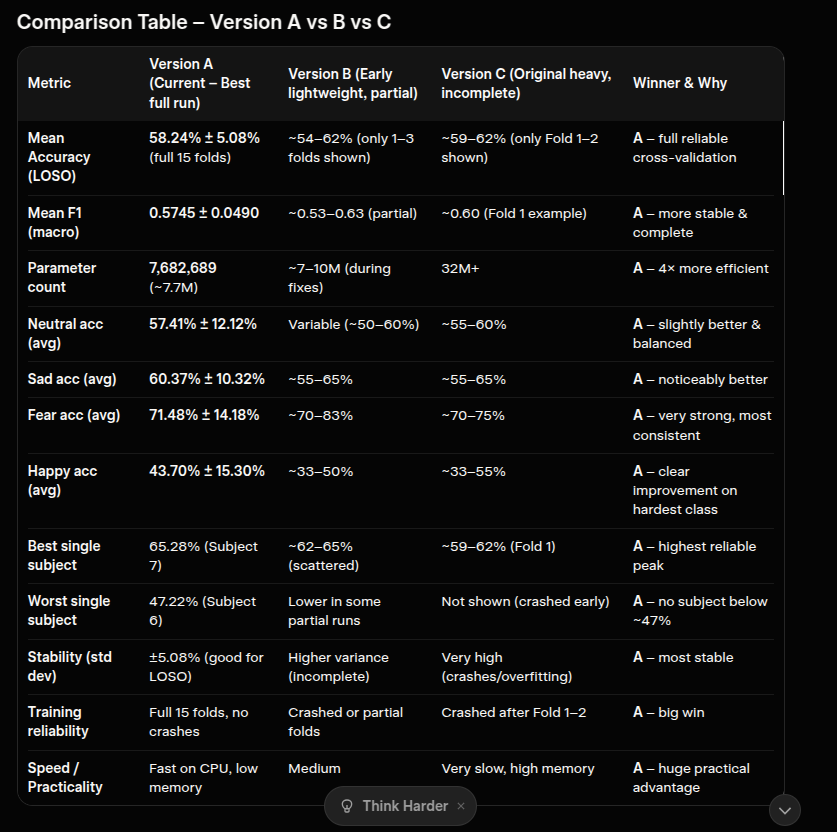